In [ ]:
# This notebook can be used to process flight files and generate pickled files of correlator+drone data

In [1]:
## First import general packages for running python analysis:
import os, h5py, datetime,pytz,pickle, yaml, sys
import numpy as np
from matplotlib.pyplot import *
from matplotlib import pyplot as plt

## Then import the beamcals module, use forked repository (not original):
sys.path.insert(0, '../classes/')
import corr, concat, drone
import plotting_utils as pu
import fitting_utils as fu
import geometry_utils as gu
import time_utils as tu
import site_utils as si
gbosite=si.Site('../metadata/GBO_DNS_config.npz')

# Define any channels, etc, and directories for this flight analysis

#config_directory="  "
maindir = '/hirax/DNS_freespace/TONE_july_2025/'
dronedir = maindir+'processed_flight_records/'
cdir = maindir+'TONE_iceboard_files/corr_data/'
gdir = maindir+'TONE_iceboard_files/digital_gains/' 

# define which channels in the data files are useful
crmap = [0,3,4,6,7,8,9]
chnames = ['EW_D5_auto','EW_D5_cr','NS_D5_auto','NS_D5_cr','NS_D8_auto','NS_D8_cr','ref_auto']

# from crmap, which indices are autos, which indices are ref crosses
autos = [0,2,4,6]
crosses = [1,3,5]


# define default 'good' frequency for plotting
f_ind = 304 
freqs = np.arange(800,400,-400./1024)
print(freqs[f_ind])

###################
#### FUNCTIONS ####
###################

def get_mag_phase(power0):
    """
    # return magnitude and phase in degrees of correlations
    """
    return np.absolute(power0), np.rad2deg(np.angle(power0))

def get_freq(i):
    di = 400/1024
    return 800-(i*di)

def get_freq_i(f):
    di = 400/1024
    i = int((f-800)/(-1.*di))
    return i

681.25


## 1. Find Correspondence between drone flight file and correlator data

In [ ]:
# RFI flight
dfile = '20250714T135821Z_WVUc52'
flyfile = 'Jul-14th-2025-10-14AM-Flight-Airdata.csv'

# flights on 07/17
# 
dfile = '20250717T160156Z_WVUc52'
flyfile='Jul-17th-2025-12-16PM-Flight-Airdata.csv'

# 
dfile = '20250717T160156Z_WVUc52'
flyfile='Jul-17th-2025-12-47PM-Flight-Airdata.csv'

#  
dfile = '20250717T160156Z_WVUc52'
flyfile = 'Jul-17th-2025-01-51PM-Flight-Airdata.csv'

#
dfile = '20250717T192717Z_WVUc52'
flyfile = 'Jul-17th-2025-04-07PM-Flight-Airdata.csv'

#
dfile = '20250717T192717Z_WVUc52'
flyfile = 'Jul-17th-2025-04-39PM-Flight-Airdata.csv'

#
dfile = '20250717T234526Z_WVUc52'
flyfile = 'Jul-17th-2025-07-56PM-Flight-Airdata.csv'

#
dfile = '20250717T234526Z_WVUc52'
flyfile = 'Jul-17th-2025-08-47PM-Flight-Airdata.csv'

#
dfile = '20250718T152104Z_WVUc52'
flyfile = 'Jul-18th-2025-11-49AM-Flight-Airdata.csv'

#
dfile = '20250718T152104Z_WVUc52'
flyfile = 'Jul-18th-2025-12-21PM-Flight-Airdata.csv'

# 
dfile = '20250718T152104Z_WVUc52'
flyfile = 'Jul-18th-2025-12-53PM-Flight-Airdata.csv'

#
dfile = '20250718T183125Z_WVUc52'
flyfile = 'Jul-18th-2025-02-55PM-Flight-Airdata.csv'

#
dfile = '20250718T183125Z_WVUc52'
flyfile = 'Jul-18th-2025-03-27PM-Flight-Airdata.csv'

# RFI flight
#dfile = '20250719T000859Z_WVUc52'
#flyfile = 'Jul-18th-2025-08-33PM-Flight-Airdata.csv'

# RFI flight
#dfile = '20250719T183054Z_WVUc52'
#flyfile = 'Jul-19th-2025-02-39PM-Flight-Airdata.csv'

######### LEAVE THIS #############################################
# this handles the wierd directory structure in the iceboard dirs
ddir = cdir+dfile+'/corr/'
di = os.listdir(ddir)[0]
datadir = ddir+str(di)+'/'
gaindir = gdir+dfile+'_digitalgain/'
print(datadir,gaindir)



In [3]:
with open('../metadata/DNS_GBO_flights_forscripts_LBN.yaml', 'r') as fff:
    documents = yaml.safe_load(fff)
flights = documents["flight_info"]["flights"]
descrip = documents["flight_info"]["desc"]
good_freqs = documents["freq_info"]["good_freqs"]

for f,fly in enumerate(flights):
    fly = flights[f]
    tub = documents["flight_info"]["tubs"][f] # this is lowest interesting index in drone data
    tlb = documents["flight_info"]["tlbs"][f] # this is highest interesting index in drone data
    cdat = documents["flight_info"]["cdats"][f]
    tclb = documents["flight_info"]["tclbs"][f]
    tcub = documents["flight_info"]["tcubs"][f]
    fmax = documents["flight_info"]["fmaxes"][f]
    fmin = documents["flight_info"]["fmins"][f]
    descrip = documents["flight_info"]["desc"][f]
    pols = documents["flight_info"]["pols"][f]
    print(fly, cdat, tlb, tub, tclb, tcub, fmin,fmax,descrip,pols)
    



Jul-14th-2025-10-14AM-Flight-Airdata.csv 20250714T135821Z_WVUc52 0 -1 0 -1 94 229 NS N
Jul-17th-2025-12-16PM-Flight-Airdata.csv 20250717T160156Z_WVUc52 700 11700 1846 28077 87 202 NS N
Jul-17th-2025-12-47PM-Flight-Airdata.csv 20250717T160156Z_WVUc52 750 11300 1816 26971 261 380 NS N
Jul-17th-2025-01-51PM-Flight-Airdata.csv 20250717T160156Z_WVUc52 700 11600 1894 27884 616 730 NS E
Jul-17th-2025-04-07PM-Flight-Airdata.csv 20250717T192717Z_WVUc52 800 11000 2095 26418 228 348 NS E
Jul-17th-2025-04-39PM-Flight-Airdata.csv 20250717T192717Z_WVUc52 700 11500 1864 27615 408 520 EW N
Jul-17th-2025-07-56PM-Flight-Airdata.csv 20250717T234526Z_WVUc52 700 11500 1900 27651 63 188 NW N
Jul-17th-2025-08-47PM-Flight-Airdata.csv 20250717T234526Z_WVUc52 700 11500 1826 27582 348 471 NW N
Jul-18th-2025-11-49AM-Flight-Airdata.csv 20250718T152104Z_WVUc52 750 11600 1824 27695 158 284 NW N
Jul-18th-2025-12-21PM-Flight-Airdata.csv 20250718T152104Z_WVUc52 750 11600 1915 27785 340 461 EW E
Jul-18th-2025-12-53PM-Fl

In [26]:
#################################################################    
#################################################################
################## PICK YOUR FLIGHT HERE ############################
#################################################################
#################################################################
# airdata files are not very easily subscriptable, 
# cluge for now by knowing which flight order is in the yaml

f = 1


fly = flights[f]
tub = documents["flight_info"]["tubs"][f] # this is lowest interesting index in drone data
tlb = documents["flight_info"]["tlbs"][f] # this is highest interesting index in drone data
cdat = documents["flight_info"]["cdats"][f]
tclb = documents["flight_info"]["tclbs"][f]
tcub = documents["flight_info"]["tcubs"][f]
fmax = documents["flight_info"]["fmaxes"][f]
fmin = documents["flight_info"]["fmins"][f]


ddir = cdir+cdat+'/corr/'
di = os.listdir(ddir)[0]
datadir = ddir+str(di)+'/'
gaindir = gdir+cdat+'_digitalgain/'
print('Using data directory: ',datadir)
print('Using gain directory: ',gaindir)

print('You chose this flight: ', fly, tub, tlb, tclb, tcub, cdat,fmin,fmax)

Using data directory:  /hirax/DNS_freespace/TONE_july_2025/TONE_iceboard_files/corr_data/20250717T160156Z_WVUc52/corr/20250717T160253Z/
Using gain directory:  /hirax/DNS_freespace/TONE_july_2025/TONE_iceboard_files/digital_gains/20250717T160156Z_WVUc52_digitalgain/
You chose this flight:  Jul-17th-2025-12-16PM-Flight-Airdata.csv 11700 700 1846 28077 20250717T160156Z_WVUc52 87 202


Initializing drone data via Airdata.csv routine: Jul-17th-2025-12-16PM-Flight-Airdata.csv
  --> Skipping rows 1 to 1199 to eliminate NAN values
  --> generating llh, geocentric cartesian, local cartesian, and local spherical coordinates.
  --> generating dish and receiver line of sight coordinates.
DONE reading in drone data
2025-07-17 16:20:54.900000+00:00 2025-07-17 16:39:14.900000+00:00


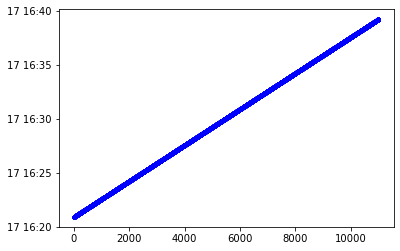

plotting drone coordinates for all time samples:
overplotting drone coordinates for t_cut samples: [0:-1]


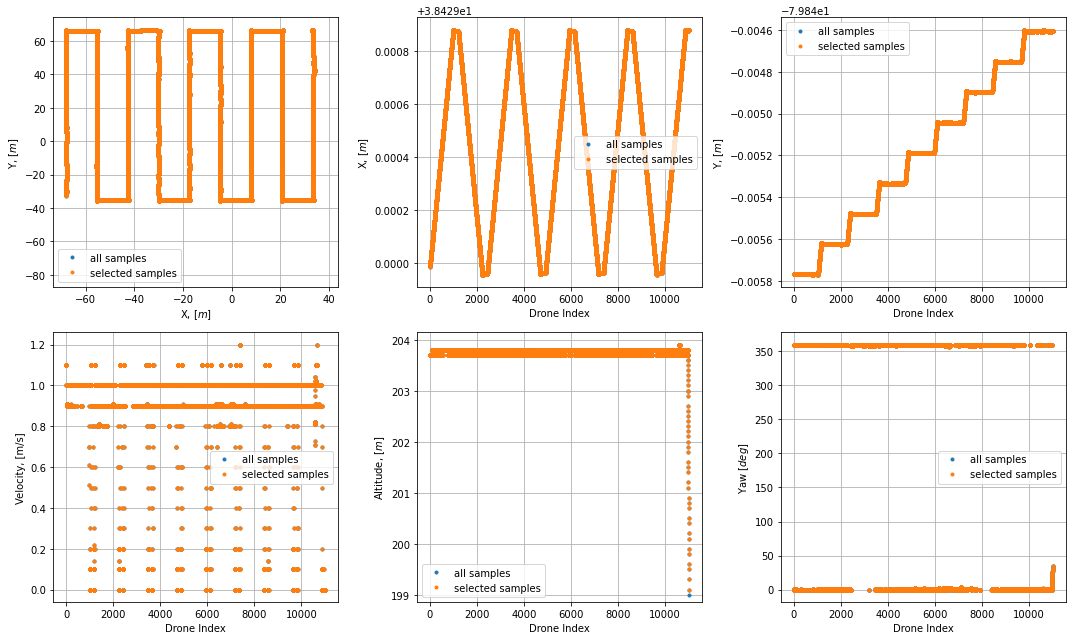

In [27]:
dronedata=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG=fly,site_class=gbosite,tlb=tlb,tub=tub)

print('DONE reading in drone data')
print(dronedata.t_arr_datetime[0], dronedata.t_arr_datetime[-1])

plt.plot(dronedata.t_arr_datetime,'b.',label='drone')
plt.show()

pu.Plot_Drone_Coordinates(dronedata,coo='xy')#,t_bounds=[tlb,tub])
#pu.Plot_Drone_Coordinates(dronetest0825,coo='xy',t_bounds=[tlb,tub])

In [ ]:
#pu.Animate_Drone_Flight(
#    dronedata, gbosite,
#    step=50,
#    manual_north_shift_m=0,
#    manual_east_shift_m=0,
#    start_time_est="12:16:00",  # optional, EST
#    end_time_est="12:40:00",    # optional, EST
#    start_percent=0.0,
#    end_percent=1,
#    interval=50,
#    center_dish=5,
#    show_dishes=[5, 8]
#)

# # Which channels are interesting?
#fd=h5py.File(datadir+'/0095', 'r')

#print(fd['vis'].shape) # time, freq, product
#print(fd['index_map']['time']['fpga_count'].shape)
#
#for i in [0,1,4,5]:#np.arange(0,10):
#    plt.plot(abs(fd['vis'][:,f_ind,i]),label=str(i)) # both real and imag are informative
#plt.legend()
#plt.plot()
#plt.show()
#
#
#for i in [2,3,6,7,8,9]:#np.arange(0,10):
#    plt.plot(abs(fd['vis'][:,f_ind,i]),label=str(i)) # both real and imag are informative
#plt.legend()
#plt.ylim(0,10000)
#plt.plot()

# channels which should have some signal: [0,3,4,6,7,8,9]

start time:  2025-10-01 13:52:42.098110
Initializing Correlator Class using:
  --> /hirax/DNS_freespace/TONE_july_2025/TONE_iceboard_files/corr_data/20250717T160156Z_WVUc52/corr/20250717T160253Z/
  --> Arrays initialized with shape (115, 256, 1024, 4)
Assigning array values by reading in data files:
  --> Loading File: 0201/0201
  --> Finished. Reshaping arrays.
end time:  2025-10-01 13:54:43.743821


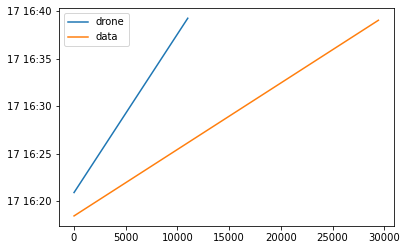

In [28]:
## Combine drone and correlator data
print('start time: ', datetime.datetime.now())

####################################################
########### load gains or not!!!!?????? ############
####################################################

lg = False

corrdata=corr.Corr_Data(Data_Directory=datadir,
                    Gain_Directory=gaindir,site_class=gbosite,
                    Load_Gains=lg,use_ctime=True,
                    crossmap=crmap,Data_File_Index=[int(fmin),int(fmax)])


    
print('end time: ', datetime.datetime.now())

# putting checks in one cell now that I know I've mostly figured out the flight/corr file correspondence
# This checks I copied and pasted ok :)

## plot their datetime arrays to check overlap:

plot(dronedata.t_arr_datetime,label='drone')
plot(corrdata.t_arr_datetime,label='data')
legend()


In [29]:
# Match drone and correlator data together, and plot a few frequencies

concatdata=concat.CONCAT(CORRDATCLASS=corrdata,DRONEDATCLASS=dronedata,\
                             load_yaml=False,traceback=False,save_traceback=False)


In [ ]:
## Plot these if you set gains = False in reading in the corr data
plotthis = True

if lg == False and plotthis == True:
    # Check some waterfalls, etc

    for j in autos:
        fig=figure(figsize=(16,8))
        plt.imshow(abs(concatdata.V_cross[:,:,j]),aspect='auto')
        #plt.xlim(tclb,tcub)
        plt.title(chnames[j])
        plt.colorbar()
        plt.show()
    for j in crosses:
        fig=figure(figsize=(16,8))
        plt.imshow(abs(concatdata.V_cross[:,:,j]),aspect='auto',vmin=0,vmax=10000)
        #plt.xlim(tclb,tcub)
        plt.title(chnames[j])
        plt.colorbar()
        plt.show()
        
if lg == True and plotthis == True:
    print('Beam maps without any time correction or pulse calculation')
    for j in np.arange(0,len(crmap)):
        plt.scatter(concatdata.drone_xyz_LC_interp[:,0],concatdata.drone_xyz_LC_interp[:,1],
                c=abs(concatdata.V_cross[:,f_ind,j]))
        plt.colorbar()
        plt.xlabel('X [m]')
        plt.ylabel('Y [m]')
        plt.title(chnames[j])
        plt.show()
    
    print('Plot the gains')
    # lets check gain application
    print(gaindir)
    gainfile=os.listdir(gaindir)[0]
    fg = h5py.File(gaindir+gainfile, 'r')
    gain_coeffs=fg['gain_coeff'][0] 
    gain_exp=fg['gain_exp'][0]
    digital_gain=fg['gain_coeff'][0] 
    digital_gain*=np.power(2,fg['gain_exp'][0])[np.newaxis,:]

    for j in np.arange(0,len(digital_gain[0,:])):
        plt.semilogy(freqs,digital_gain[:,j],label=str(j))
    plt.legend()
    plt.show()

    # plot waterfalls 

    print('Plotting waterfalls of autocorrelations')
    # waterfall of autos
    vmin=-100
    vmax=-92
    for j in autos:
        fig=figure(figsize=(16,8))
        plt.imshow(10*np.log10(abs(concatdata.V_cross[:,:,j])),aspect='auto',vmin=vmin,vmax=vmax)
        #plt.xlim(tclb,tcub)
        plt.title(chnames[j])
        plt.colorbar()
        plt.show()
    
    print('plotting waterfalls of dish x reference')
    # waterfall of crosses
    vmin=-140
    vmax=-100
    for j in crosses:
        fig=figure(figsize=(16,8))
        plt.imshow(10*np.log10(abs(concatdata.V_cross[:,:,j])),aspect='auto',vmin=vmin,vmax=vmax)
        #plt.xlim(tclb,tcub)
        plt.title(chnames[j])
        plt.colorbar()
        plt.show()

In [ ]:
## Look at a basic spectrum (ylims assume you read in gains)

mean_perch = np.std(abs(concatdata.V_cross),axis=0) # time, freq,ch
max_perch = np.max(abs(concatdata.V_cross),axis=0) # time, freq,ch

fig=figure(figsize=(16,8))
for j in np.arange(0,len(crmap)):
    plt.plot(freqs,max_perch[:,j],'.',label=chnames[j])
plt.legend()
plt.ylim(0,1E-9)
plt.title('MAX value across time')
plt.show()

fig=figure(figsize=(16,8))
for j in np.arange(0,len(crmap)):
    plt.plot(freqs,mean_perch[:,j],'.',label=chnames[j])
plt.legend()
plt.ylim(0,0.2E-9)
plt.title('MEAN value across time')
plt.show()

In [ ]:
## Look at a basic map

for j in np.arange(0,len(crmap)):
    plt.scatter(concatdata.drone_xyz_LC_interp[:,0],concatdata.drone_xyz_LC_interp[:,1],c=concatdata.V_cross[:,f_ind,j])
    plt.colorbar()
    plt.xlabel('X [m]')
    plt.ylabel('Y [m]')
    plt.title(chnames[j])
    plt.show()

In [ ]:
## Look at something near the central transit

print(concatdata.V_cross.shape)
print(freqs[f_ind])

plb = 9000
pub = 11000

for j in np.arange(0,len(crmap)):
    fig=figure(figsize=(16,8))
    plt.plot(concatdata.t_index[:],abs(concatdata.V_cross[:,f_ind,j]),'.')
    plt.xlim(tclb,tcub)
    plt.title(chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    #plt.xlim(plb,pub)
    plt.show()

In [ ]:
## OBJECTIVE 5A: concat Function: Extract_Source_Pulses

## Let's use the Extract_Source_Pulses function:
    # The Period and Dutycycle options are known beforehand, and given in microseconds.
    # The t_bounds option just determines the plot bounds, not the solving routine.
## Fortunately, these parameters are loaded from the config, so we don't have to wait for the solver to run.
    ## The returned t_delta_pulse parameter will be given in seconds.
    ## In the verification plot, we should see the following points plotted:
        # orange_o = inds_off  = times when the source is off
        # blue_o   = inds_on   = times when the source is on and broadcasting
        # green_x  = inds_span = times where the behavior changes during the integration period (omit always!)
    ## The print statements shows the list of indices that appear in more than one of on/off/span.
        ## If they are all empty lists [], then there is no overlap which is a good thing.
concatdata.traceback=False
print('start time: ', datetime.datetime.now())
concatdata.Extract_Source_Pulses(Period=0.99999e6,Dutycycle=0.5e6,t_bounds=[0,-1],f_ind=f_ind, use_ref_channel=3)

print('end time: ', datetime.datetime.now())

In [ ]:
# aside to look at the span, on, and off indices in more detail

chind = 6
t_cut = concatdata.inds_on
t_span = concatdata.inds_span
t_off = concatdata.inds_off
N = len(t_cut)
N2 = int(N/2)
print(len(t_cut),len(t_span),len(t_off))
plt.figure(1,figsize=(10,10))

plt.plot(concatdata.t_arr_datetime[t_cut],concatdata.V_cross[t_cut,f_ind,chind],'b.',label='on')
plt.plot(concatdata.t_arr_datetime[t_span],concatdata.V_cross[t_span,f_ind,chind],'gx',label='span')
plt.plot(concatdata.t_arr_datetime[t_off],concatdata.V_cross[t_off,f_ind,chind],'r.',label='off')
plt.xlim(concatdata.t_arr_datetime[t_cut[N2]],concatdata.t_arr_datetime[t_cut[N2+300]])
plt.legend()
plt.show()

In [ ]:
# plot abs value somewhere around the transit

for j in np.arange(0,len(crmap)):
    fig=figure(figsize=(16,8))
    plt.plot(concatdata.t_arr_datetime[t_cut],abs(concatdata.V_cross[t_cut,f_ind,j]),'b.',label='on')
    plt.plot(concatdata.t_arr_datetime[t_span],abs(concatdata.V_cross[t_span,f_ind,j]),'gx',label='span')
    plt.plot(concatdata.t_arr_datetime[t_off],abs(concatdata.V_cross[t_off,f_ind,j]),'r.',label='off')
    #plt.xlim(tclb,tcub)
    plt.title(chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    #plt.xlim(plb,pub)
    plt.legend()
    plt.show()

In [ ]:
# plot real and imaginary components somewhere around the transit

for j in np.arange(0,len(crmap)):
    fig=figure(figsize=(16,8))
    plt.plot(concatdata.t_arr_datetime[t_cut],concatdata.V_cross[t_cut,f_ind,j].real,'b.',label='on')
    plt.plot(concatdata.t_arr_datetime[t_span],concatdata.V_cross[t_span,f_ind,j].real,'gx',label='span')
    plt.plot(concatdata.t_arr_datetime[t_off],concatdata.V_cross[t_off,f_ind,j].real,'r.',label='off')
    #plt.xlim(tclb,tcub)
    plt.title('REAL '+chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    #plt.xlim(plb,pub)
    plt.legend()
    plt.show()
    
for j in np.arange(0,len(crmap)):
    fig=figure(figsize=(16,8))
    plt.plot(concatdata.t_arr_datetime[t_cut],concatdata.V_cross[t_cut,f_ind,j].imag,'b.',label='on')
    plt.plot(concatdata.t_arr_datetime[t_span],concatdata.V_cross[t_span,f_ind,j].imag,'gx',label='span')
    plt.plot(concatdata.t_arr_datetime[t_off],concatdata.V_cross[t_off,f_ind,j].imag,'r.',label='off')
    #plt.xlim(tclb,tcub)
    plt.title('IMAG '+chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    #plt.xlim(plb,pub)
    plt.legend()
    plt.show()

In [ ]:
# map the on times

for j in np.arange(0,len(crmap)):
    plt.scatter(concatdata.drone_xyz_LC_interp[t_cut,0],concatdata.drone_xyz_LC_interp[t_cut,1],
            c=10*np.log10(concatdata.V_cross[t_cut,f_ind,j]),s=10.0,
            cmap='gnuplot2')
    #plt.xlim(-40,40)
    #plt.ylim(-40,40)
    plt.title(chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    plt.colorbar()
    plt.show()

In [ ]:
# waterfall of autos
print('Plotting waterfalls of autocorrelations')


cmap = cm.jet
cmap.set_bad('red') # Set NaNs to white


vmin=-100
vmax=-92
for j in autos:
    fig=figure(figsize=(16,8))
    plt.imshow(10*np.log10(abs(concatdata.V_cross[t_cut,:,j])),aspect='auto',vmin=vmin,vmax=vmax)
    #plt.xlim(tclb,tcub)
    plt.title(chnames[j])
    plt.colorbar()
    plt.show()

print('plotting waterfalls for crosses')
# waterfall of crosses
vmin=-140
vmax=-100
for j in crosses:
    fig=figure(figsize=(16,8))
    plt.imshow(10*np.log10(abs(concatdata.V_cross[t_cut,:,j])),aspect='auto',vmin=vmin,vmax=vmax)
    #plt.xlim(tclb,tcub)
    plt.title(chnames[j])
    plt.colorbar()
    plt.show()

In [ ]:
## OBJECTIVE 5B: concat Function: Perform_Background_Subtraction

## Let's do background subtraction: creates computed background (V_bg) and background-subtracted (V_bgsub) arrays:
    # window_size=5 - this is 1/2 the width of the 'index window' across which the background is averaged.
    # This function only works if the source was pulsed and Extract_Source_Pulses was used!
concatdata.Perform_Background_Subtraction(window_size=15)

In [ ]:
# lets check if there are any NaNs after background subtraction (there shouldn't be)

print(concatdata.V_cross.shape)
print(concatdata.V_bgsub.shape)
print(concatdata.V_cross_bgsub.shape)
#print(f_ind)
#print(concatdata.t_index)

j=0
print(abs(concatdata.V_cross[t_cut,f_ind,j]))
print(abs(concatdata.V_cross[t_off,f_ind,j]))
print(concatdata.V_cross_bgsub[t_cut,f_ind,j])

nan_count_numpy = np.count_nonzero(np.isnan(concatdata.V_cross_bgsub[t_cut,f_ind,j]))
print(f"NaN count in NumPy array: {nan_count_numpy}")

In [ ]:
# look at the background subtracted data around transit

for j in np.arange(0,len(crmap)):
    fig=figure(figsize=(16,8))
    plt.plot(concatdata.t_arr_datetime[t_cut],concatdata.V_cross_bgsub[t_cut,f_ind,j].real,'b.')
    #plt.xlim(tclb,tcub)
    plt.title('REAL '+chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    #plt.xlim(plb,pub)
    plt.legend()
    plt.show()
    
for j in np.arange(0,len(crmap)):
    fig=figure(figsize=(16,8))
    plt.plot(concatdata.t_arr_datetime[t_cut],concatdata.V_cross_bgsub[t_cut,f_ind,j].imag)
    plt.title('IMAG '+chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    #plt.xlim(plb,pub)
    plt.legend()
    plt.show()

# Off higher than on at some frequencies in the autocorrelation data????

In [ ]:


cmap = cm.Greys
cmap.set_bad('blue') # Set NaNs to white

lb = 0#4000#4400
ub = 20000#5000#4800

lf = 0
uf = 1021

for j in np.arange(0,len(crmap)):
    #fig=figure(figsize=(16,8))
    #for f in np.arange(uf-10,uf):
    #    plt.plot(concatdata.V_cross_bgsub[t_cut[lb:ub],f,j].real,label=str(f))
    #plt.legend()
    #plt.title(chnames[j])
    #plt.show()


    #fig=figure(figsize=(16,8))
    #plt.imshow(
    #    np.sign(concatdata.V_cross_bgsub[t_cut[lb:ub],lf:uf,j].real)*10*np.log10(abs(concatdata.V_cross_bgsub[t_cut[lb:ub],lf:uf,j].real)),
    #       cmap=cmap,aspect='auto',vmin=-110,vmax=110)
    #plt.title(chnames[j])
    #plt.colorbar()
    #plt.show()
    
    fig=figure(figsize=(16,8))
    plt.imshow(
        np.sign(concatdata.V_cross_bgsub[t_cut[lb:ub],lf:uf,j].real),
           cmap=cmap,aspect='auto',extent=[freqs[lf],freqs[uf],ub,lb])
    plt.title(chnames[j])
    plt.colorbar()
    plt.axvline(freqs[300],color='red')
    plt.show()


In [ ]:
cmap = cm.Greys
cmap.set_bad('blue') # Set NaNs to white

lb = 4000#4400
ub = 5000#4800

# first comb
flb = 650
fub = 750
lf=get_freq_i(fub)
uf=get_freq_i(flb)
tslice1 = 4600
comb = np.arange(flb+2.2,fub,3.3)
print(comb)

# extended comb
flb = 620
fub = 750
lf=get_freq_i(fub)
uf=get_freq_i(flb)
tslice1 = 4600
comb = np.arange(flb+2.5,fub,3.3)
print(comb)

    
for j in autos[0:3]: 
    fig=figure(figsize=(16,8))
    plt.imshow(
        np.sign(concatdata.V_cross_bgsub[t_cut[lb:ub],lf:uf,j].real),
           cmap=cmap,aspect='auto',extent=[freqs[lf],freqs[uf],ub,lb])
    plt.axhline(tslice1,color='orange')
    plt.title(chnames[j])
    plt.colorbar()
    plt.axvline(freqs[300],color='orange')
    for c in comb:
        plt.axvline(c,color='red')
    plt.show()

fig=figure(figsize=(16,8))
for j in autos[0:3]:    
    plt.plot(freqs[lf:uf],np.sign(concatdata.V_cross_bgsub[tslice1,lf:uf,j].real)+0.1*j,
             marker='.',linestyle='None',label=chnames[j])
    plt.axvline(freqs[300],color='red')
plt.legend()
plt.xlim(650,700)
plt.show()


# Which frequencies might be useful for beam mapping?????

In [ ]:
# should be able to catch these two cases:

f = 300
for j in autos[0:2]:
    fig=figure(figsize=(8,4))
    plt.plot(concatdata.V_cross_bgsub[t_cut,f,j].real,'b.',label='on')
    plt.axvline(tslice,color='black')
    plt.show()
    
f = 600
j = crosses[0]
fig=figure(figsize=(8,4))
plt.plot(concatdata.V_cross[t_off,f,j].real,'r.',label='off')
plt.axvline(tslice,color='black')
plt.show()

In [ ]:
# Find good frequencies, use D5 NS (autos[1])
ja = autos[1]
jc = crosses[1]
good_freqs = []
for f in np.arange(0,1024):
    ok_backauto0 = concatdata.V_cross_bgsub[t_cut[tslice1],f,autos[0]].real
    ok_backauto1 = concatdata.V_cross_bgsub[t_cut[tslice1],f,autos[1]].real
    ok_offcross0 = np.std(concatdata.V_cross[t_off[tslice-100:tslice+100],f,crosses[0]].real,axis=0)
    if np.sign(ok_backauto0) > 0 and np.sign(ok_backauto1) >0 and ok_offcross0 < 0.6E-13:
        #np.mean(abs(concatdata.V_cross[t_off[4400:4800],f,jc].real),axis=0) < 1E-12 
        good_freqs.append(f)
   
print(len(good_freqs))
plt.plot(freqs[good_freqs],good_freqs,'b.')
plt.show()

j = autos[0]
f_ind = good_freqs[0]

fig=figure(figsize=(16,8))
plt.plot(np.mean(abs(concatdata.V_cross[t_off[4400:4800],:,j].real),axis=0),'b.')
plt.plot(f_ind,np.mean(abs(concatdata.V_cross[t_off[4400:4800],f_ind,j].real),axis=0),'r*')
#plt.ylim(0,0.1E-12)
#plt.axhline(0.6E-13,color='red')
#plt.ylim(0,1E-12)
plt.show()
         

j = crosses[0]
fig=figure(figsize=(16,8))
plt.plot(concatdata.t_arr_datetime[t_cut],abs(concatdata.V_cross[t_cut,f_ind,j]),'b.',label='on')
plt.plot(concatdata.t_arr_datetime[t_off],abs(concatdata.V_cross[t_off,f_ind,j]),'r.',label='off')
#plt.xlim(tclb,tcub)
plt.title(chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
plt.legend()
plt.show()

print(good_freqs)

In [ ]:
j=crosses[0]
for f in good_freqs[::4]:
    fig=figure(figsize=(8,4))
    plt.plot(concatdata.V_cross[t_cut,f,j].real,'b.',label='on')
    plt.plot(concatdata.V_cross[t_off,f,j].real,'r.',label='off')
    #plt.title('REAL '+chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    #plt.legend()
    plt.show()

# Quick check of whether I did the time stamps correctly in the corr class ....

In [2]:
f = 1


fly = flights[f]
tub = documents["flight_info"]["tubs"][f] # this is lowest interesting index in drone data
tlb = documents["flight_info"]["tlbs"][f] # this is highest interesting index in drone data
cdat = documents["flight_info"]["cdats"][f]
tclb = documents["flight_info"]["tclbs"][f]
tcub = documents["flight_info"]["tcubs"][f]
fmax = documents["flight_info"]["fmaxes"][f]
fmin = documents["flight_info"]["fmins"][f]


ddir = cdir+cdat+'/corr/'
di = os.listdir(ddir)[0]
datadir = ddir+str(di)+'/'
gaindir = gdir+cdat+'_digitalgain/'
print('Using data directory: ',datadir)
print('Using gain directory: ',gaindir)

print('You chose this flight: ', fly, tub, tlb, tclb, tcub, cdat,fmin,fmax)

NameError: name 'flights' is not defined

In [ ]:
# get time stamps and fpga counts for beginning and end of file 0, 87, 202 
filelist = np.sort([x for x in os.listdir(datadir) if ".lock" not in x])[:-1]

for i in [0,87,202]:
    fd=h5py.File(datadir+filelist[i], 'r')
    print('filename: ',filelist[i], 
          ' Start time: ', datetime.datetime.utcfromtimestamp(fd['index_map']['time']['ctime'][0]), 
          ' End time: ', datetime.datetime.utcfromtimestamp(fd['index_map']['time']['ctime'][-1]))
    print('Start fpga count: ',fd['index_map']['time']['fpga_count'][0], 
          ' End fpga count: ',fd['index_map']['time']['fpga_count'][-1])
    print('Delta Timestamp :', fd['index_map']['time']['ctime'][-1] - fd['index_map']['time']['ctime'][0])
    print('Delta fpga counts: ',2.56E-6*(fd['index_map']['time']['fpga_count'][-1]-fd['index_map']['time']['fpga_count'][0]))

In [ ]:
# read in only file 0

corrdata=corr.Corr_Data(Data_Directory=datadir,
                    Gain_Directory=gaindir,site_class=gbosite,
                    Load_Gains=False,use_ctime=True,
                    crossmap=crmap,Data_File_Index=[0,1])

print('File 0 times: ',corrdata.t_arr_datetime[0],corrdata.t_arr_datetime[-1])

# read in only file 87
corrdata=corr.Corr_Data(Data_Directory=datadir,
                    Gain_Directory=gaindir,site_class=gbosite,
                    Load_Gains=False,use_ctime=True,
                    crossmap=crmap,Data_File_Index=[87,88])

print('File 87 times: ',corrdata.t_arr_datetime[0],corrdata.t_arr_datetime[-1])

# read in only file 202
corrdata=corr.Corr_Data(Data_Directory=datadir,
                    Gain_Directory=gaindir,site_class=gbosite,
                    Load_Gains=False,use_ctime=True,
                    crossmap=crmap,Data_File_Index=[202,203])

print('File 202 times: ',corrdata.t_arr_datetime[0],corrdata.t_arr_datetime[-1])

In [ ]:
# read files 0-87 and re-check:

# read in only file 202
corrdata=corr.Corr_Data(Data_Directory=datadir,
                    Gain_Directory=gaindir,site_class=gbosite,
                    Load_Gains=False,use_ctime=True,
                    crossmap=crmap,Data_File_Index=[0,87])

print('File 202 times: ',corrdata.t_arr_datetime[0],corrdata.t_arr_datetime[-1])

In [ ]:
# read files 87 to 202 and re-check:

# read in only file 202
corrdata=corr.Corr_Data(Data_Directory=datadir,
                    Gain_Directory=gaindir,site_class=gbosite,
                    Load_Gains=False,use_ctime=True,
                    crossmap=crmap,Data_File_Index=[87,202])

print('File 202 times: ',corrdata.t_arr_datetime[0],corrdata.t_arr_datetime[-1])

In [ ]:
# read files 0 to 202 and re-check:

# read in only file 202
corrdata=corr.Corr_Data(Data_Directory=datadir,
                    Gain_Directory=gaindir,site_class=gbosite,
                    Load_Gains=False,use_ctime=True,
                    crossmap=crmap,Data_File_Index=[0,202])

print('File 202 times: ',corrdata.t_arr_datetime[0],corrdata.t_arr_datetime[-1])

In [ ]:
# ok, the ctimes and the corr times don't precisely match, but it isn't minutes off. 
# Lets concat and see what happens

corrdata=corr.Corr_Data(Data_Directory=datadir,
                    Gain_Directory=gaindir,site_class=gbosite,
                    Load_Gains=False,use_ctime=True,
                    crossmap=crmap,Data_File_Index=[87,202])

print('corrdata times: ',corrdata.t_arr_datetime[0],corrdata.t_arr_datetime[-1])

dronedata=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG=fly,site_class=gbosite,tlb=tlb,tub=tub)

print('DONE reading in drone data')
print(dronedata.t_arr_datetime[0], dronedata.t_arr_datetime[-1])

concatdata=concat.CONCAT(CORRDATCLASS=corrdata,DRONEDATCLASS=dronedata,\
                             load_yaml=False,traceback=False,save_traceback=False)

print(concatdata.t_arr_datetime[0],concatdata.t_arr_datetime[-1])



In [ ]:
print(concatdata.t_arr_datetime[0],concatdata.t_arr_datetime[-1])
f_ind = 304

for j in np.arange(0,len(crmap[0:1])):
    plt.scatter(concatdata.drone_xyz_LC_interp[:,0],concatdata.drone_xyz_LC_interp[:,1],
            c=10*np.log10(concatdata.V_cross[:,f_ind,j]),s=10.0,
            cmap='gnuplot2')
    #plt.xlim(-40,40)
    #plt.ylim(-40,40)
    plt.title(chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    plt.colorbar()
    plt.show()


In [ ]:
corrdata=corr.Corr_Data(Data_Directory=datadir,
                    Gain_Directory=gaindir,site_class=gbosite,
                    Load_Gains=False,use_ctime=True,
                    crossmap=crmap,Data_File_Index=[86,202])

print('corrdata times: ',corrdata.t_arr_datetime[0],corrdata.t_arr_datetime[-1])

dronedata=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG=fly,site_class=gbosite,tlb=tlb,tub=tub)

print('DONE reading in drone data')
print(dronedata.t_arr_datetime[0], dronedata.t_arr_datetime[-1])

concatdata=concat.CONCAT(CORRDATCLASS=corrdata,DRONEDATCLASS=dronedata,\
                             load_yaml=False,traceback=False,save_traceback=False)

print(concatdata.t_arr_datetime[0],concatdata.t_arr_datetime[-1])

for j in np.arange(0,len(crmap[0:1])):
    plt.scatter(concatdata.drone_xyz_LC_interp[:,0],concatdata.drone_xyz_LC_interp[:,1],
            c=10*np.log10(concatdata.V_cross[:,f_ind,j]),s=10.0,
            cmap='gnuplot2')
    #plt.xlim(-40,40)
    #plt.ylim(-40,40)
    plt.title(chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    plt.colorbar()
    plt.show()


In [ ]:
concatdata=concat.CONCAT(CORRDATCLASS=corrdata,DRONEDATCLASS=dronedata,\
                             load_yaml=False,traceback=False,save_traceback=False,t_drone_offset=-15)

print(concatdata.t_arr_datetime[0],concatdata.t_arr_datetime[-1])

for j in np.arange(0,len(crmap[0:1])):
    plt.scatter(concatdata.drone_xyz_LC_interp[:,0],concatdata.drone_xyz_LC_interp[:,1],
            c=10*np.log10(concatdata.V_cross[:,f_ind,j]),s=10.0,
            cmap='gnuplot2')
    #plt.xlim(-40,40)
    #plt.ylim(-40,40)
    plt.title(chnames[j] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    plt.colorbar()
    plt.show()


In [4]:
# Morgan's check:
# Use files 85-88 corr only

with open('../metadata/DNS_GBO_flights_forscripts_LBN.yaml', 'r') as fff:
    documents = yaml.safe_load(fff)
flights = documents["flight_info"]["flights"]
descrip = documents["flight_info"]["desc"]
good_freqs = documents["freq_info"]["good_freqs"]

for f,fly in enumerate(flights):
    fly = flights[f]
    tub = documents["flight_info"]["tubs"][f] # this is lowest interesting index in drone data
    tlb = documents["flight_info"]["tlbs"][f] # this is highest interesting index in drone data
    cdat = documents["flight_info"]["cdats"][f]
    tclb = documents["flight_info"]["tclbs"][f]
    tcub = documents["flight_info"]["tcubs"][f]
    fmax = documents["flight_info"]["fmaxes"][f]
    fmin = documents["flight_info"]["fmins"][f]
    descrip = documents["flight_info"]["desc"][f]
    pols = documents["flight_info"]["pols"][f]
    print(fly, cdat, tlb, tub, tclb, tcub, fmin,fmax,descrip,pols)

f = 1


fly = flights[f]
tub = documents["flight_info"]["tubs"][f] # this is lowest interesting index in drone data
tlb = documents["flight_info"]["tlbs"][f] # this is highest interesting index in drone data
cdat = documents["flight_info"]["cdats"][f]
tclb = documents["flight_info"]["tclbs"][f]
tcub = documents["flight_info"]["tcubs"][f]
fmax = documents["flight_info"]["fmaxes"][f]
fmin = documents["flight_info"]["fmins"][f]


ddir = cdir+cdat+'/corr/'
di = os.listdir(ddir)[0]
datadir = ddir+str(di)+'/'
gaindir = gdir+cdat+'_digitalgain/'
print('Using data directory: ',datadir)
print('Using gain directory: ',gaindir)

print('You chose this flight: ', fly, tub, tlb, tclb, tcub, cdat,fmin,fmax)


Jul-14th-2025-10-14AM-Flight-Airdata.csv 20250714T135821Z_WVUc52 0 -1 0 -1 94 229 NS N
Jul-17th-2025-12-16PM-Flight-Airdata.csv 20250717T160156Z_WVUc52 700 11700 1846 28077 87 202 NS N
Jul-17th-2025-12-47PM-Flight-Airdata.csv 20250717T160156Z_WVUc52 750 11300 1816 26971 261 380 NS N
Jul-17th-2025-01-51PM-Flight-Airdata.csv 20250717T160156Z_WVUc52 700 11600 1894 27884 616 730 NS E
Jul-17th-2025-04-07PM-Flight-Airdata.csv 20250717T192717Z_WVUc52 800 11000 2095 26418 228 348 NS E
Jul-17th-2025-04-39PM-Flight-Airdata.csv 20250717T192717Z_WVUc52 700 11500 1864 27615 408 520 EW N
Jul-17th-2025-07-56PM-Flight-Airdata.csv 20250717T234526Z_WVUc52 700 11500 1900 27651 63 188 NW N
Jul-17th-2025-08-47PM-Flight-Airdata.csv 20250717T234526Z_WVUc52 700 11500 1826 27582 348 471 NW N
Jul-18th-2025-11-49AM-Flight-Airdata.csv 20250718T152104Z_WVUc52 750 11600 1824 27695 158 284 NW N
Jul-18th-2025-12-21PM-Flight-Airdata.csv 20250718T152104Z_WVUc52 750 11600 1915 27785 340 461 EW E
Jul-18th-2025-12-53PM-Fl

Initializing drone data via Airdata.csv routine: Jul-17th-2025-12-16PM-Flight-Airdata.csv
  --> Skipping rows 1 to 499 to eliminate NAN values
  --> generating llh, geocentric cartesian, local cartesian, and local spherical coordinates.
  --> generating dish and receiver line of sight coordinates.
DONE reading in drone data
2025-07-17 16:18:34.900000+00:00 2025-07-17 16:40:05.300000+00:00


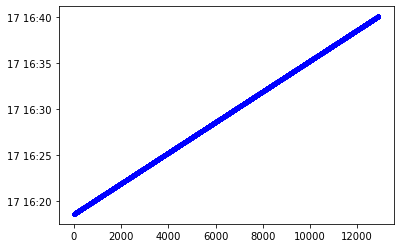

plotting drone coordinates for all time samples:
overplotting drone coordinates for t_cut samples: [0:-1]


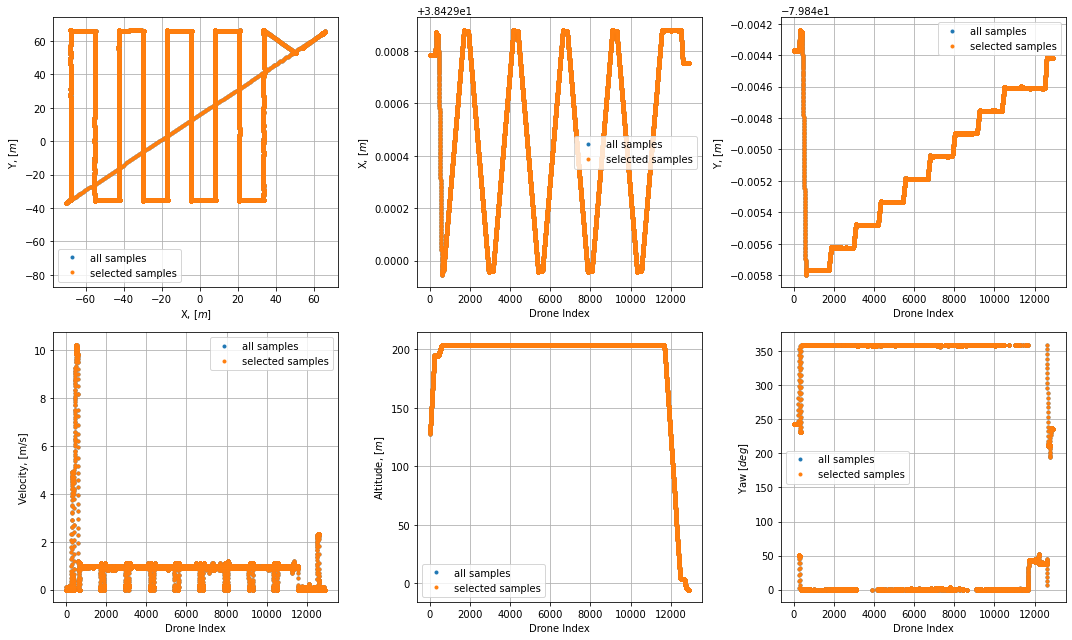

In [4]:
dronedata=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG=fly,site_class=gbosite)

print('DONE reading in drone data')
print(dronedata.t_arr_datetime[0], dronedata.t_arr_datetime[-1])

plt.plot(dronedata.t_arr_datetime,'b.',label='drone')
plt.show()

pu.Plot_Drone_Coordinates(dronedata,coo='xy')#,t_bounds=[tlb,tub])
#pu.Plot_Drone_Coordinates(dronetest0825,coo='xy',t_bounds=[tlb,tub])

start time:  2025-10-01 09:40:07.043054
Initializing Correlator Class using:
  --> /hirax/DNS_freespace/TONE_july_2025/TONE_iceboard_files/corr_data/20250717T160156Z_WVUc52/corr/20250717T160253Z/
  --> Arrays initialized with shape (3, 256, 1024, 4)
Assigning array values by reading in data files:
  --> Loading File: 0087/0087
  --> Finished. Reshaping arrays.
end time:  2025-10-01 09:40:07.786728


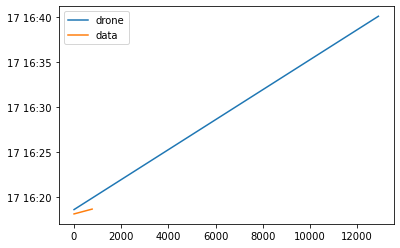

In [6]:
## Combine drone and correlator data
print('start time: ', datetime.datetime.now())

####################################################
########### load gains or not!!!!?????? ############
####################################################

lg = False

corrdata=corr.Corr_Data(Data_Directory=datadir,
                    Gain_Directory=gaindir,site_class=gbosite,
                    Load_Gains=lg,use_ctime=True,
                    crossmap=crmap,Data_File_Index=[85,88])


    
print('end time: ', datetime.datetime.now())


plot(dronedata.t_arr_datetime,label='drone')
plot(corrdata.t_arr_datetime,label='data')
legend()

2025-07-17 16:17:45+00:00 2025-07-17 16:39:16+00:00
2025-07-17 16:18:34.900000+00:00 2025-07-17 16:40:05.300000+00:00
2025-07-17 16:18:05.926542+00:00 2025-07-17 16:18:38.096854+00:00


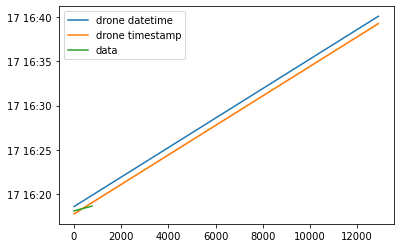

In [20]:
print(dronedata.t_arr_timestamp[0],dronedata.t_arr_timestamp[-1])
print(dronedata.t_arr_datetime[0],dronedata.t_arr_datetime[-1])
print(corrdata.t_arr_datetime[0],corrdata.t_arr_datetime[-1])

# try to find overlap region
plot(dronedata.t_arr_datetime,label='drone datetime')
plot(dronedata.t_arr_timestamp,label='drone timestamp')
plot(corrdata.t_arr_datetime,label='data')
legend()

In [5]:
import pandas
skip_rows = skip_rows = np.arange(1,500).tolist()
drone_data=pandas.read_csv(dronedir+fly,skiprows=skip_rows,low_memory=False)
t_arr_timestamp=np.array(pandas.to_datetime(drone_data['datetime(utc)'],utc=True),dtype='object')
t0=t_arr_timestamp[0]
print(t0)
dts=[datetime.timedelta(milliseconds=x) for x in drone_data['time(millisecond)']]
print(dts[0])
#print(drone_data)

2025-07-17 16:17:45+00:00
0:00:49.900000


In [6]:
t0=t_arr_timestamp[0]
print(t0)

print(1E-3*np.array(drone_data['time(millisecond)']))
t0=t_arr_timestamp[0] - datetime.timedelta(seconds=1E-3*np.array(drone_data['time(millisecond)'])[0])
print(t0)

2025-07-17 16:17:45+00:00
[  49.9   50.    50.1 ... 1340.1 1340.2 1340.3]
2025-07-17 16:16:55.100000+00:00


In [8]:
dronedata=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG=fly,site_class=gbosite)

print('DONE reading in drone data')
print(dronedata.t_arr_datetime[0], dronedata.t_arr_datetime[-1])
print(dronedata.t_arr_timestamp[0], dronedata.t_arr_timestamp[-1])

Initializing drone data via Airdata.csv routine: Jul-17th-2025-12-16PM-Flight-Airdata.csv
  --> Skipping rows 1 to 499 to eliminate NAN values
  --> generating llh, geocentric cartesian, local cartesian, and local spherical coordinates.
  --> generating dish and receiver line of sight coordinates.
DONE reading in drone data
2025-07-17 16:17:45+00:00 2025-07-17 16:39:15.400000+00:00
2025-07-17 16:17:45+00:00 2025-07-17 16:39:16+00:00


In [10]:
diffs = np.zeros(len(dronedata.t_arr_datetime))
for i in np.arange(1,len(dronedata.t_arr_datetime)):
    diffs[i] = dronedata.t_arr_timestamp[i] - dronedata.t_arr_timestamp[i-1]
plt.plot(diffs)
plt.show()

TypeError: float() argument must be a string or a number, not 'Timedelta'

In [ ]:
print(corrdata.t_arr_datetime[0],corrdata.t_arr_datetime[-1])
print(concatdata.t_arr_datetime[0],concatdata.t_arr_datetime[-1])

(29440, 1024, 7)


/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


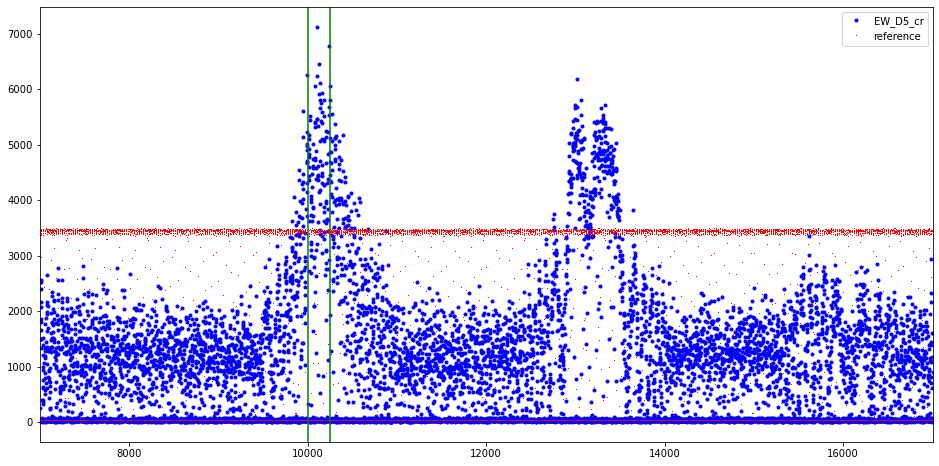

/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


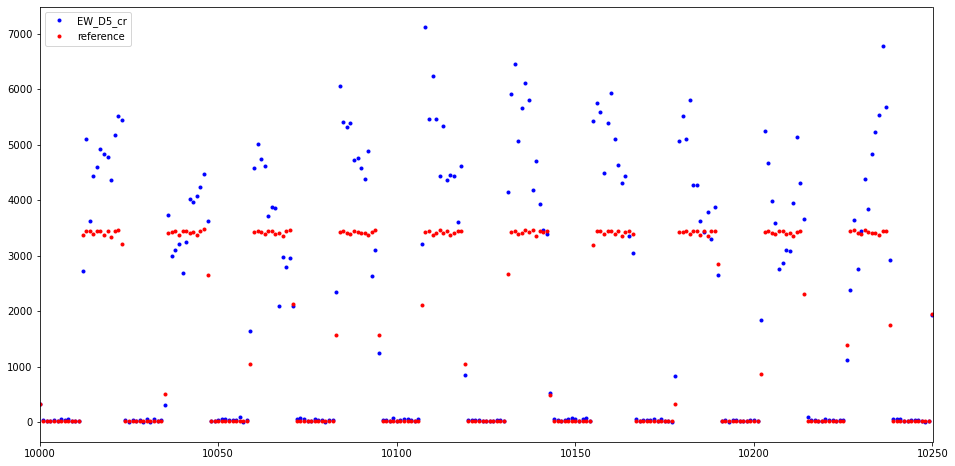

/home/ln267/anaconda3/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1289: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


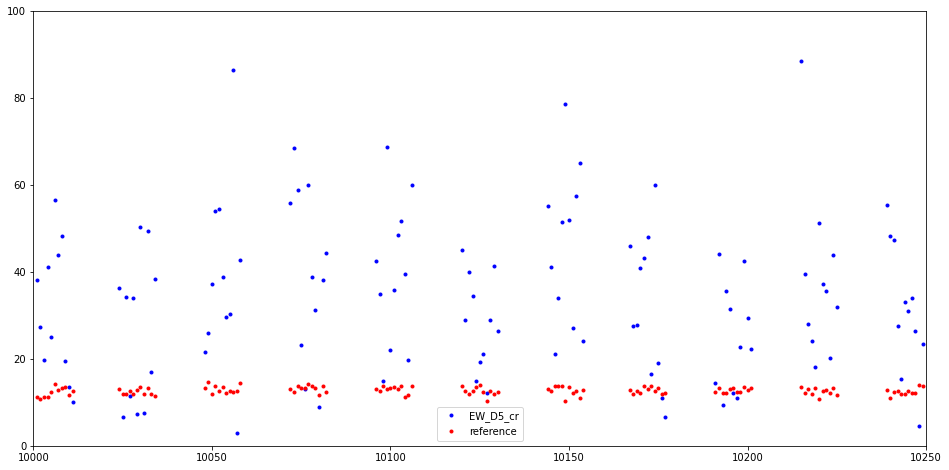

In [60]:
## Checking the pulse on/off-ness
f_ind = 304
chind = 1
print(corrdata.V_cross.shape) # time, freq, input (6 is ref)
lb = 10000
ub = 10250

# full range
fig=figure(figsize=(16,8))
plt.plot(abs(corrdata.V_cross[:,f_ind,1]),'b.',label=chnames[chind])
plt.plot(corrdata.V_cross[:,304,6]*0.5E-1,'r,',label='reference')
plt.axvline(lb,color='green')
plt.axvline(ub,color='green')
plt.legend()
plt.xlim(7000,17000)
plt.show()

fig=figure(figsize=(16,8))
plt.plot(abs(corrdata.V_cross[:,f_ind,1]),'b.',label=chnames[chind])
plt.plot(corrdata.V_cross[:,304,6]*0.5E-1,'r.',label='reference')
plt.legend()
plt.xlim(lb,ub)
#plt.ylim(3000,6000)
plt.show()

fig=figure(figsize=(16,8))
plt.plot(abs(corrdata.V_cross[:,f_ind,1]),'b.',label=chnames[chind])
plt.plot(corrdata.V_cross[:,304,6]*0.5E-1,'r.',label='reference')
plt.legend()
plt.xlim(lb,ub)
plt.ylim(0,100)
plt.show()